<span style="color:blue"> Changes in this version - use cohort data without ICD duplicate removal for sequence frequence check. </span>

In [1]:
import pandas as pd
import numpy as np

### 1. Building the sequences 

Event sequences are built upon the statistically significantly associated disease pairs identified using the DCN methods. We will limit the length of the sequence to 1-4 events.

In [2]:
import os
print(os.getcwd())

/workspaces/disease_trajectory_predictive_ML


In [3]:
%cd C:/Users/yxing/Documents/projects/Kothari/WHIO/Event_sequence_analysis

[Errno 2] No such file or directory: 'C:/Users/yxing/Documents/projects/Kothari/WHIO/Event_sequence_analysis'
/workspaces/disease_trajectory_predictive_ML


In [4]:
#load the data file that contains the names of the significantly associated disease pairs
df1=pd.read_excel('gastric_sig_pairs_121525.xlsx')

In [5]:
#drop gastric_cancer from list
df1=df1[df1['to_disease']!='gastric_cancer']

In [6]:
#generate 2-event, 3-events and 4-events sequences
import networkx as nx
from collections import defaultdict

# Build a directed graph
G = nx.DiGraph()
for _, row in df1.iterrows():
    G.add_edge(row["from_disease"], row["to_disease"])

def generate_sequences(G, max_len=4):
    sequences_by_length = defaultdict(list)
    
    def dfs(path):
        if 2 <= len(path) <= max_len:
            sequences_by_length[len(path)].append(path[:])
        if len(path) < max_len:
            last = path[-1]
            for neighbor in G.successors(last):
                if neighbor not in path:  # prevent cycles
                    dfs(path + [neighbor])
    
    for node in G.nodes():
        dfs([node])
    
    return sequences_by_length

# Generate sequences grouped by length
sequences_by_length = generate_sequences(G, max_len=4)

# Convert to readable dict with counts
result = {
    f"{k}-event": {
        "count": len(v),
        "sequences": ["-".join(seq) for seq in v]
    }
    for k, v in sequences_by_length.items()
}


In [7]:
#load the gastric cancer cohort data
df2=pd.read_csv('gastric_cancer_dcn_3l_v2.csv', low_memory=False)

In [8]:
df2.head()

,Whio_MemberId,event,ServiceDate,Age_dx,Sex,Encounter_type
0,WHIO1000970,C22,2023-12-22,72.0,M,Outpatient
1,WHIO1000970,D12,2023-03-16,71.0,M,Outpatient
2,WHIO1000970,D13,2023-06-12,71.0,M,Outpatient
3,WHIO1000970,D50,2018-07-03,66.0,M,Outpatient
4,WHIO1000970,D50,2018-05-22,66.0,M,Outpatient


In [9]:
# Sort by person and date
df2 = df2.sort_values(["Whio_MemberId", "ServiceDate"])

# Example sequences from df1
sequences = result
# Function to check if a sequence exists in a list of events
def has_subsequence(events, seq):
    seq = seq.split("-")
    i = 0
    for e in events:
        if e == seq[i]:
            i += 1
            if i == len(seq):
                return True
    return False

# Build results table
rows = []
for category, v in sequences.items():
    for seq in v["sequences"]:
        count = (
            df2.groupby("Whio_MemberId")["event"]
            .apply(lambda ev: has_subsequence(ev.tolist(), seq))
            .sum()
        )
        rows.append([category, seq, count])

result_table = pd.DataFrame(rows, columns=["Category", "Sequence", "Frequency"])


In [10]:
gastric_seq_freq=result_table.sort_values("Frequency",ascending=False)

In [11]:
gastric_seq_freq.head()

,Category,Sequence,Frequency
137,2-event,K21-K22,290
131,2-event,E66-E11,237
138,2-event,K21-K31,226
97,2-event,E11-E87,215
95,2-event,D64-E87,200


In [12]:
gastric_seq_freq['Sequence'].nunique()

1122

### 3. Check the sequence frequencies in the non-gastric cohort

In [13]:
#load the non-gastric cancer cohort data
df3=pd.read_csv('non_gastric_cancer_dcn_3l_v2.csv')

In [14]:
df3=df3.sort_values(["Whio_MemberId", "ServiceDate"])
# Build results table
rows = []
for category, v in sequences.items():
    for seq in v["sequences"]:
        count = (
            df3.groupby("Whio_MemberId")["event"]
            .apply(lambda ev: has_subsequence(ev.tolist(), seq))
            .sum()
        )
        rows.append([category, seq, count])

non_gastric_seq_freq = pd.DataFrame(rows, columns=["Category", "Sequence", "Frequency"])


In [15]:
non_gastric_seq_freq=non_gastric_seq_freq.sort_values('Frequency',ascending=False)

### 4. Check if the frequencies differ significantly between the cohort

In [16]:
from scipy.stats import chi2_contingency, fisher_exact

# Merge on sequence
merged = gastric_seq_freq.merge(non_gastric_seq_freq, on=["Category","Sequence"], suffixes=("_gastric","_non_gastric"))

# Run tests
results = []
for _, row in merged.iterrows():
    a = row["Frequency_gastric"]
    b = row["Frequency_non_gastric"]
    
    # Build 2x2 contingency: [ [count in A, count not in A], [count in B, count not in B] ]
    contingency = [[a, sum(gastric_seq_freq["Frequency"]) - a],
                   [b, sum(non_gastric_seq_freq["Frequency"]) - b]]
    
    # Convert to numpy array and add correction for zeros
    contingency = np.array(contingency, dtype=float)
    contingency[contingency == 0] = 0.5  # add correction only to zeros
    
    # Use Fisher's exact for small counts, otherwise chi-square
    if a < 5 or b < 5:
        _, p = fisher_exact(contingency)
    else:
        chi2, p, _, _ = chi2_contingency(contingency)
    
    results.append([row["Category"], row["Sequence"], a, b, p])

# Build results table
stats_table = pd.DataFrame(results, columns=["Category","Sequence","Freq_gastric","Freq_non_gastric","p_value"])

In [17]:
#keep the ones with p-value <0.05
filtered_seqs=stats_table[stats_table['p_value']<0.05]

In [18]:
filtered_seqs.shape

(369, 5)

In [19]:
# filtered_seqs[filtered_seqs['Freq_gastric']>filtered_seqs['Freq_non_gastric']]

There are 445 sequences with frequencies that are significantly different between the two cohorts.

In [20]:
#keep sequences that have at least 20 counts in the gastric cancer patients group
high_freq=filtered_seqs[filtered_seqs['Freq_gastric']>=20]
len(high_freq)

144

In [21]:
positive_seq=high_freq[high_freq['Freq_gastric']>high_freq['Freq_non_gastric']]
len(positive_seq)

21

In [22]:
filtered_seqs.to_csv('sig_seqs_012826.csv',index=False)

### 5. Create columns with sequence names, if a patient has that sequence, it will be labeled as 1, also creating a columns of the starting date of the sequence ; if that patient doesn't have that sequence, it's labeled as 0, the starting date is set to None

#### 5.1. Prepare the gastric cancer cohort

In [23]:
df=df2[['Whio_MemberId', 'event', 'ServiceDate']]
df['ServiceDate']=pd.to_datetime(df['ServiceDate'])
# sequences = filtered_seqs['Sequence'].unique()
sequences = high_freq['Sequence'].unique()
# Helper function: check subsequence and return start and end dates if found
def subsequence_start(events, dates, subseq):
    subseq = subseq.split("-")  # e.g. "a-b" -> ["a", "b"]
    m = len(subseq)
    i = 0
    start_date = None
    end_date = None

    for j, ev in enumerate(events):
        if ev == subseq[i]:
            if i == 0:
                start_date = dates[j].date()  # first match
            i += 1
            if i == m:
                end_date = dates[j].date()   # last match
                return 1, start_date, end_date

    return 0, None, None

# Aggregate events & dates per ID
df_sorted = df.sort_values(["Whio_MemberId","ServiceDate"])
agg = df_sorted.groupby("Whio_MemberId").agg({"event": list, "ServiceDate": list})

# Result dataframe
result = pd.DataFrame(index=agg.index)
## Add last event date per ID
result["last_event_date"] = agg["ServiceDate"].apply(lambda d: d[-1].date())
# Add columns for each sequence
for seq in sequences:
    result[seq] = 0
    result[seq + "_start"] = None
    
    for idx, row in agg.iterrows():
        flag, start_date,end_date = subsequence_start(row["event"], row["ServiceDate"], seq)
        result.at[idx, seq] = flag
        result.at[idx, seq + "_start"] = start_date
        result.at[idx, seq + "_end"] = end_date


/tmp/ipykernel_10017/3690834373.py:34: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  result[seq] = 0
/tmp/ipykernel_10017/3690834373.py:35: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  result[seq + "_start"] = None
/tmp/ipykernel_10017/3690834373.py:41: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  

In [24]:
gastric_seq_df=result.copy()

In [25]:
#get demographics date
df2_demographics=df2.drop(['event', 'ServiceDate','Encounter_type'],axis=1)
df2_demographics=df2_demographics.drop_duplicates()
#keep the oldest age
idx = df2_demographics.groupby("Whio_MemberId")["Age_dx"].idxmax()
df2_dmg =df2_demographics.loc[idx].reset_index(drop=True)

In [26]:
df2_dmg.shape

(2466, 3)

In [27]:
gastric_seq_df.shape

(2466, 433)

In [28]:
#merge with age_dx, sex columns in df2
gastric_final=pd.merge(df2_dmg,gastric_seq_df,on='Whio_MemberId',how='left')

In [29]:
#add a column called gastric cancer
gastric_final['gastric_cancer_dx']=1

In [30]:
# gastric_final.head()

#### 6.2. Prepare the non-gastric cancer cohort

In [31]:
df=df3[['Whio_MemberId', 'event', 'ServiceDate']]
df['ServiceDate']=pd.to_datetime(df['ServiceDate'])

# Aggregate events & dates per ID
df_sorted = df.sort_values(["Whio_MemberId","ServiceDate"])
agg = df_sorted.groupby("Whio_MemberId").agg({"event": list, "ServiceDate": list})

# Result dataframe
result = pd.DataFrame(index=agg.index)
## Add last event date per ID
result["last_event_date"] = agg["ServiceDate"].apply(lambda d: d[-1].date())
# Add columns for each sequence
for seq in sequences:
    result[seq] = 0
    result[seq + "_start"] = None
    
    for idx, row in agg.iterrows():
        flag, start_date,end_date = subsequence_start(row["event"], row["ServiceDate"], seq)
        result.at[idx, seq] = flag
        result.at[idx, seq + "_start"] = start_date
        result.at[idx, seq + "_end"] = end_date

/tmp/ipykernel_10017/3472784516.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  result[seq] = 0
/tmp/ipykernel_10017/3472784516.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  result[seq + "_start"] = None
/tmp/ipykernel_10017/3472784516.py:21: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  

In [32]:
non_gastric_seq_df=result.copy()

In [33]:
#get demographics data
df3_demographics=df3.drop(['event', 'ServiceDate','Encounter_type'],axis=1)
df3_demographics=df3_demographics.drop_duplicates()

In [34]:
df3_demographics.shape

(4353, 3)

In [35]:
#merge with age_dx, sex columns in df2
non_gastric_final=pd.merge(df3_demographics,non_gastric_seq_df,on='Whio_MemberId',how='left')

In [36]:
#add a column 'gastric_cancer_dx'
non_gastric_final['gastric_cancer_dx']=0

#### 5.3. Combine the two dataset row-wise

In [37]:
#rename age for both columns to be consistent
gastric_final=gastric_final.rename(columns={'Age_dx':'Age'})
non_gastric_final=non_gastric_final.rename(columns={'Age_last_dx':'Age'})

In [38]:
#merge the two datasets
gastric_seq_analysis=pd.concat([gastric_final,non_gastric_final],ignore_index=True)

In [39]:
gastric_seq_analysis.shape

(6819, 437)

In [40]:
gastric_seq_analysis.to_csv('gastric_seq_analysis_data_012826.csv')

### 6. Analysis

In [41]:
df_analysis=gastric_seq_analysis.copy()

In [42]:
#drop all the sequence starting dates columns
df_analysis=df_analysis.loc[:,~df_analysis.columns.str.endswith('_start')]

In [43]:
#convert sex to 1-M and 0-F
df_analysis['Sex']=df_analysis['Sex'].map({"M":1,"F":0})

In [44]:
df_analysis.shape

(6819, 293)

In [45]:
df_analysis['gastric_cancer_dx'].value_counts()

gastric_cancer_dx
0    4353
1    2466
Name: count, dtype: int64

In [46]:
df_analysis = df_analysis.drop(
    columns=df_analysis.columns[df_analysis.columns.str.contains('_(start|end)$')]
)

/tmp/ipykernel_10017/1781626792.py:2: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  columns=df_analysis.columns[df_analysis.columns.str.contains('_(start|end)$')]


In [47]:
df_analysis.sample(5)

,Whio_MemberId,Age,Sex,last_event_date,K21-K22,E66-E11,K21-K31,E11-E87,D64-E87,K29-K31,...,I44-I25-E11,C18-C80,C18-K59,D72-J18-J98,D50-K25-K29,L97-I48-N18,L03-L97-E11-E87,I51-I50-N18-E87,K92-K31-K22,gastric_cancer_dx
4877,WHIO3457648,56.0,1,2024-01-15,1,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4884,WHIO3464017,67.0,1,2024-03-25,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
1302,WHIO3466042,71.0,0,2020-06-12,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2970,WHIO1534926,63.0,1,2025-04-29,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1049,WHIO2982086,58.0,1,2021-10-01,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


#### 6.1 Univariate logistic regression

In [48]:
import warnings
warnings.filterwarnings('ignore')  # Suppress warnings for cleaner output
import statsmodels.api as sm
# Your original code works fine for significance screening
df_lr = df_analysis.copy()
y_col = "gastric_cancer_dx"
X_cols = [c for c in df_lr.columns if c not in ('gastric_cancer_dx','Age','Sex')]
results = []

for col in X_cols:
    X = df_lr[[col]+['Age','Sex']].copy()
    X = sm.add_constant(X)
    y = df_lr[y_col]
    try:
        model = sm.Logit(y, X).fit(disp=0)

        # Focus on what you need: variable name and p-value
        summary = {
            "variable": col,
            "p_value": model.pvalues[col],
            "coef": model.params[col]
        }
        results.append(summary)
    except:
        print(f"Could not fit model for {col}")

univariate_results = pd.DataFrame(results)

# Find significant variables (p < 0.05)
significant_vars = univariate_results[univariate_results['p_value'] < 0.05]
# print(f"Found {len(significant_vars)} significant variables")
# print(significant_vars.sort_values('p_value'))

Could not fit model for Whio_MemberId
Could not fit model for last_event_date


In [49]:
significant_vars.to_csv("sig_univariate_012826.csv")

In [50]:
len(significant_vars)

100

In [51]:
significant_vars

,variable,p_value,coef
0,K21-K22,4.067238e-03,0.234848
1,E66-E11,1.309322e-14,0.764029
3,E11-E87,1.641534e-64,-1.357136
4,D64-E87,2.964243e-57,-1.311402
6,I25-E11,9.699234e-03,0.258613
...,...,...,...
130,L02-L97-E11,2.431828e-05,2.610736
134,I25-I50-I48-E11,4.191148e-03,1.046620
135,I44-I25-E11,6.133074e-03,0.977244
138,D72-J18-J98,5.575151e-10,-1.489207


In [52]:
positive_sig_seq=list(set(positive_seq['Sequence'].unique()) & set(significant_vars['variable'].unique()))
positive_sig_seq

['E66-E11-E87',
 'G62-I48-E11',
 'B35-L97-E11',
 'L97-I48-E11',
 'K63-C18',
 'L03-L97-E11',
 'E66-E11',
 'I73-L97-E11',
 'K44-K22-J98',
 'L02-L97-E11',
 'I25-I50-I48-E11',
 'I87-L97-E11',
 'L97-E11',
 'K56-C18',
 'D64-N18-E11',
 'L03-L97-E11-E87',
 'K44-K22',
 'I25-I50-N18-E11',
 'I44-I25-E11',
 'L97-E11-E87']

#### 6.2. Predictive modeling

In [53]:
#only use sequences that are statistically significant in the univariate analysis
seq_var=significant_vars['variable'].unique()
cols_to_select = ['Age', 'Sex','gastric_cancer_dx'] + [col for col in seq_var if col in df_lr.columns]

In [54]:
df_pred=df_lr[cols_to_select]

In [55]:
X=df_pred.drop(['gastric_cancer_dx'],axis=1)
y=df_pred['gastric_cancer_dx']

In [56]:
import seaborn as sns
import matplotlib.pyplot as plt
# # check variable colinearity
# correlation_matrix = X.corr()
# filtered_correlation = correlation_matrix.where(abs(correlation_matrix) > 0.5)
# plt.figure(figsize=(30,20))
# sns.heatmap(filtered_correlation, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
# plt.title('Correlation Matrix')
# plt.show()

In [57]:
from sklearn.model_selection import train_test_split,cross_val_score

# we will do a 80/20 train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

#### 6.3.1. Logistic regression

Classification Report: Logistic Regression
              precision    recall  f1-score   support

           0       0.88      0.85      0.87      1285
           1       0.76      0.80      0.78       761

    accuracy                           0.83      2046
   macro avg       0.82      0.83      0.82      2046
weighted avg       0.84      0.83      0.83      2046



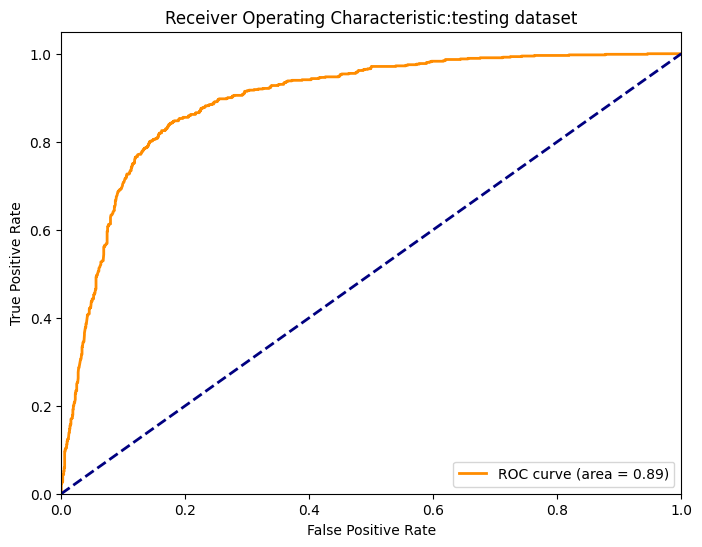

Confusion Matrix:
 [[1096  189]
 [ 151  610]]


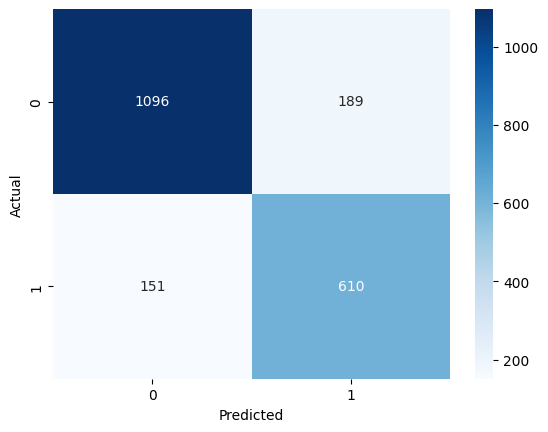

In [58]:
###Logistic regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report,precision_score,f1_score
LR_model = LogisticRegression(max_iter=500)
LR_model.fit(X_train, y_train) # we will train the model on the entire dataset
y_pred = LR_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
print("Classification Report: Logistic Regression")
print(classification_report(y_test, y_pred, zero_division=0))
from sklearn.metrics import roc_curve, auc
# Calculate the ROC curve and AUC
y_probs = LR_model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic:testing dataset')
plt.legend(loc="lower right")
plt.show()

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

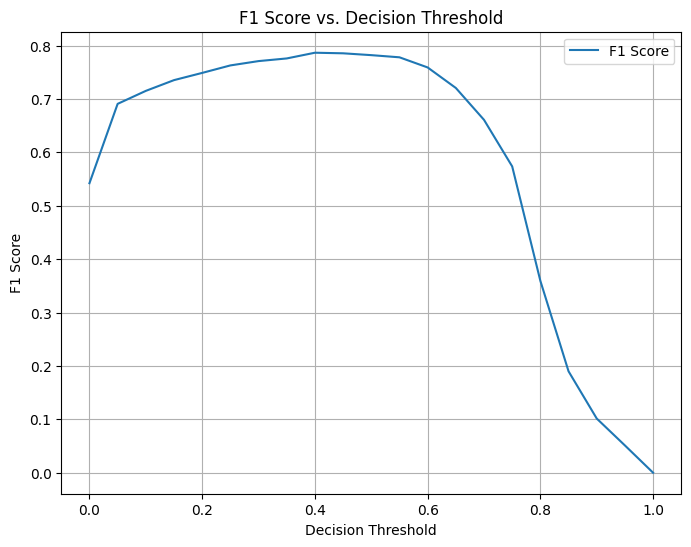

array([0.4])

In [59]:
#change the decisionthrehsold to improve model prediction 
# Define thresholds
thresholds = np.arange(0, 1.01, 0.05)

# Calculate F1 scores for each threshold
f1_scores = [f1_score(y_test, y_probs >= t) for t in thresholds]
# Find the threshold with the maximum F1 score
max_f1 = max(f1_scores)
optimal_thresholds = thresholds[np.array(f1_scores) == max_f1]
# Plot F1 score against decision threshold
plt.figure(figsize=(8, 6))
plt.plot(thresholds, f1_scores, label='F1 Score')
plt.xlabel('Decision Threshold')
plt.ylabel('F1 Score')
plt.title('F1 Score vs. Decision Threshold')
plt.grid(True)
plt.legend()
plt.show()
optimal_thresholds

In [60]:
y_pred_optimal = (y_probs >= 0.55).astype(int)
print(classification_report(y_test, y_pred_optimal))

              precision    recall  f1-score   support

           0       0.87      0.87      0.87      1285
           1       0.78      0.77      0.78       761

    accuracy                           0.84      2046
   macro avg       0.83      0.82      0.82      2046
weighted avg       0.84      0.84      0.84      2046



Classification Report: Logistic Regression, evaluated on the training dataset
              precision    recall  f1-score   support

           0       0.92      0.85      0.89      3068
           1       0.76      0.87      0.81      1705

    accuracy                           0.86      4773
   macro avg       0.84      0.86      0.85      4773
weighted avg       0.87      0.86      0.86      4773



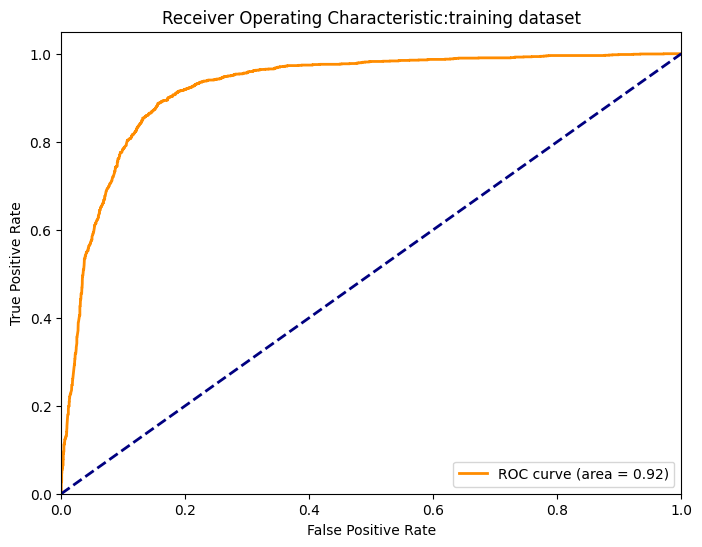

In [61]:
#troubleshooting, find out reason for poort model performance
#evaluate model on the training dataset
y_pred = LR_model.predict(X_train)
accuracy = accuracy_score(y_train, y_pred)
precision = precision_score(y_train, y_pred, zero_division=0)
print("Classification Report: Logistic Regression, evaluated on the training dataset")
print(classification_report(y_train, y_pred, zero_division=0))
from sklearn.metrics import roc_curve, auc
# Calculate the ROC curve and AUC
y_probs = LR_model.predict_proba(X_train)[:, 1]
fpr, tpr, thresholds = roc_curve(y_train, y_probs)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic:training dataset')
plt.legend(loc="lower right")
plt.show()

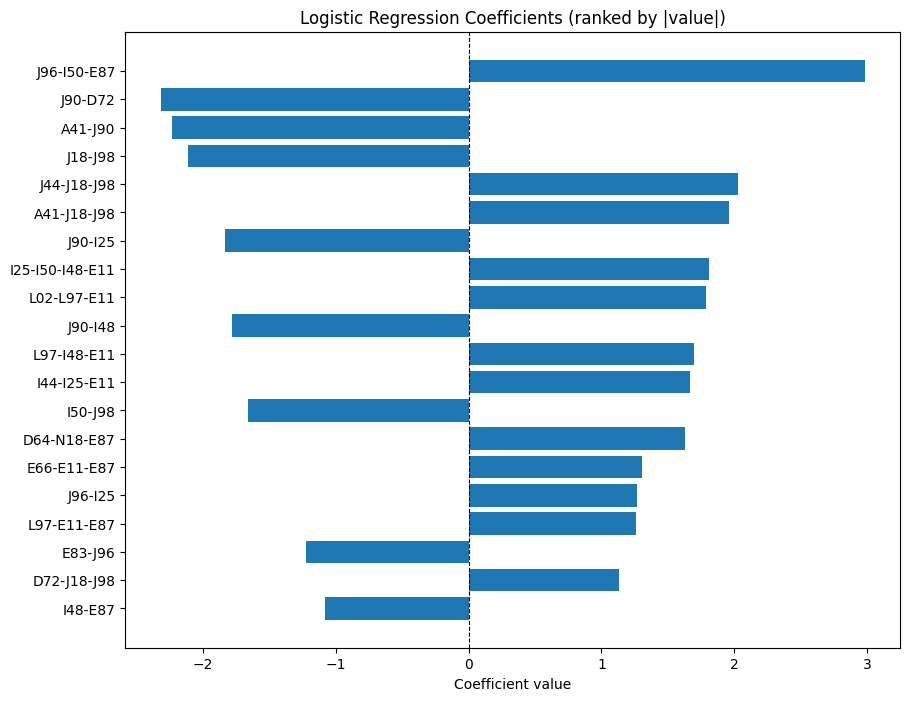

In [62]:
# Get coefficients
coef = LR_model.coef_[0]
features = X.columns

# Put into DataFrame for easy sorting
coef_df = pd.DataFrame({
    "feature": features,
    "coefficient": coef,
    "abs_coef": np.abs(coef)
})

# Sort by absolute value
coef_df = coef_df.sort_values("abs_coef", ascending=True)

# Take top 20 by absolute value
top_coef = coef_df.nlargest(20, "abs_coef").sort_values("abs_coef", ascending=True)

# Plot horizontal bar chart
plt.figure(figsize=(10,8))
plt.barh(top_coef["feature"], top_coef["coefficient"])
plt.axvline(0, color="black", linewidth=0.8, linestyle="--")
plt.title("Logistic Regression Coefficients (ranked by |value|)")
plt.xlabel("Coefficient value")
plt.show()

In [63]:
top_coef

,feature,coefficient,abs_coef
28,I48-E87,-1.079184,1.079184
100,D72-J18-J98,1.132145,1.132145
72,E83-J96,-1.225790,1.225790
78,L97-E11-E87,1.261403,1.261403
53,J96-I25,1.264623,1.264623
32,E66-E11-E87,1.301925,1.301925
55,D64-N18-E87,1.629268,1.629268
27,I50-J98,-1.659709,1.659709
99,I44-I25-E11,1.664980,1.664980
93,L97-I48-E11,1.697005,1.697005


Classification Report: Logistic Regression
              precision    recall  f1-score   support

           0       0.90      0.75      0.82      1285
           1       0.67      0.86      0.76       761

    accuracy                           0.79      2046
   macro avg       0.79      0.81      0.79      2046
weighted avg       0.82      0.79      0.80      2046



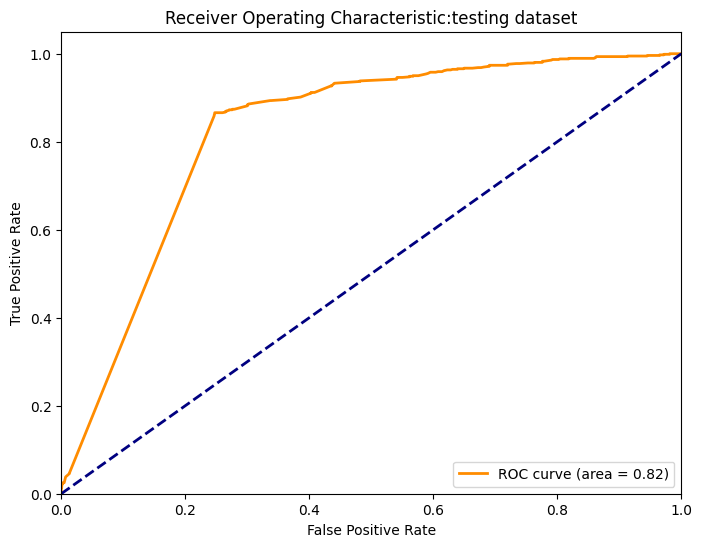

Confusion Matrix:
 [[967 318]
 [103 658]]


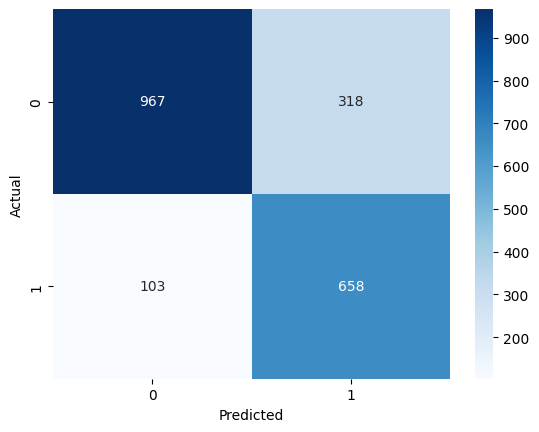

In [64]:
top_features=top_coef["feature"].tolist()
LR_top = LogisticRegression(max_iter=500)
LR_top.fit(X_train[top_features], y_train) # we will train the model on the entire dataset
y_pred = LR_top.predict(X_test[top_features])
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
print("Classification Report: Logistic Regression")
print(classification_report(y_test, y_pred, zero_division=0))
from sklearn.metrics import roc_curve, auc
# Calculate the ROC curve and AUC
y_probs = LR_top.predict_proba(X_test[top_features])[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic:testing dataset')
plt.legend(loc="lower right")
plt.show()

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

#### 6.3.2. Random forest

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1285
           1       0.83      0.71      0.76       761

    accuracy                           0.84      2046
   macro avg       0.83      0.81      0.82      2046
weighted avg       0.84      0.84      0.83      2046



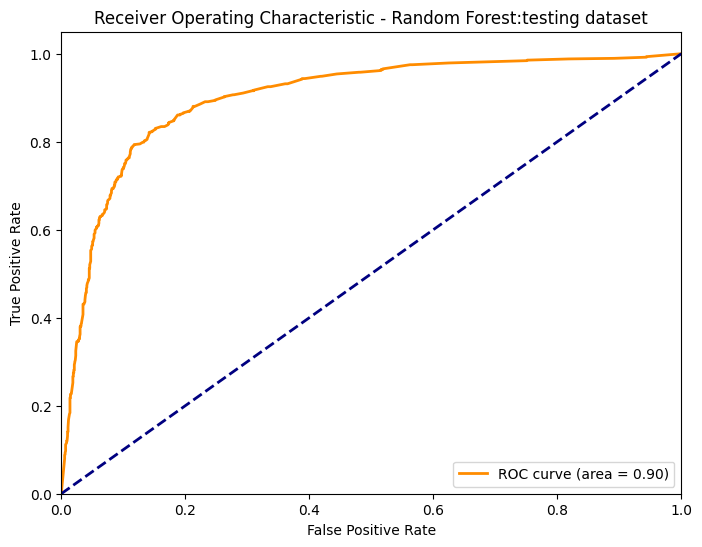

Confusion Matrix:
 [[1172  113]
 [ 222  539]]


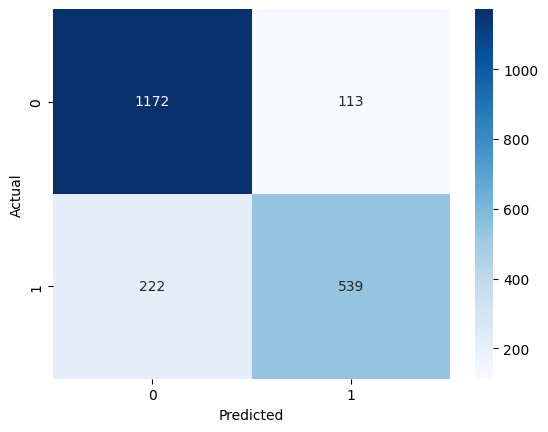

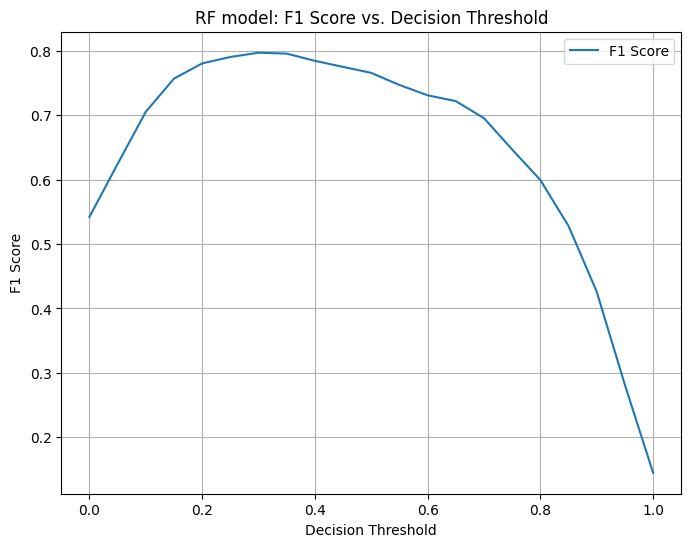

array([0.3])

In [65]:
## Random forest model
from sklearn.ensemble import RandomForestClassifier
# Train Random Forest classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred=rf_model.predict(X_test)
print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0))
# Predict probabilities
y_probs = rf_model.predict_proba(X_test)[:, 1]

# Calculate the ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic - Random Forest:testing dataset')
plt.legend(loc="lower right")
plt.show()

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

#change the decisionthrehsold to improve model prediction 
# Define thresholds
thresholds = np.arange(0, 1.01, 0.05)

# Calculate F1 scores for each threshold
f1_scores = [f1_score(y_test, y_probs >= t) for t in thresholds]
# Find the threshold with the maximum F1 score
max_f1 = max(f1_scores)
optimal_thresholds = thresholds[np.array(f1_scores) == max_f1]
# Plot F1 score against decision threshold
plt.figure(figsize=(8, 6))
plt.plot(thresholds, f1_scores, label='F1 Score')
plt.xlabel('Decision Threshold')
plt.ylabel('F1 Score')
plt.title('RF model: F1 Score vs. Decision Threshold')
plt.grid(True)
plt.legend()
plt.show()
optimal_thresholds

In [66]:
y_pred_optimal = (y_probs >= 0.35).astype(int)
print(classification_report(y_test, y_pred_optimal))

              precision    recall  f1-score   support

           0       0.88      0.87      0.88      1285
           1       0.79      0.80      0.79       761

    accuracy                           0.84      2046
   macro avg       0.83      0.83      0.83      2046
weighted avg       0.84      0.84      0.84      2046



Classification Report: Random forest, evaluated on the training dataset
              precision    recall  f1-score   support

           0       1.00      0.94      0.97      3068
           1       0.91      0.99      0.95      1705

    accuracy                           0.96      4773
   macro avg       0.95      0.97      0.96      4773
weighted avg       0.96      0.96      0.96      4773



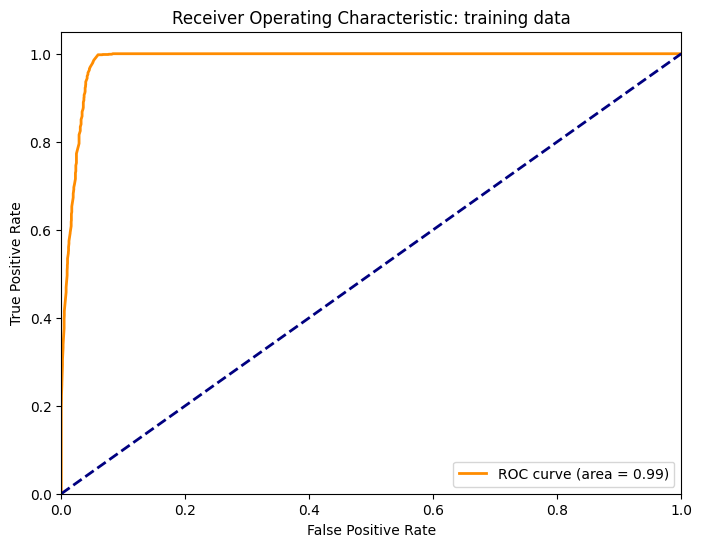

In [67]:
#troubleshooting, find out reason for poort model performance
#evaluate model on the training dataset
y_pred = rf_model.predict(X_train)
accuracy = accuracy_score(y_train, y_pred)
precision = precision_score(y_train, y_pred, zero_division=0)
print("Classification Report: Random forest, evaluated on the training dataset")
print(classification_report(y_train, y_pred, zero_division=0))
from sklearn.metrics import roc_curve, auc
# Calculate the ROC curve and AUC
y_probs = rf_model.predict_proba(X_train)[:, 1]
fpr, tpr, thresholds = roc_curve(y_train, y_probs)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic: training data')
plt.legend(loc="lower right")
plt.show()

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.91      0.93      1285
           1       0.85      0.91      0.88       761

    accuracy                           0.91      2046
   macro avg       0.90      0.91      0.90      2046
weighted avg       0.91      0.91      0.91      2046



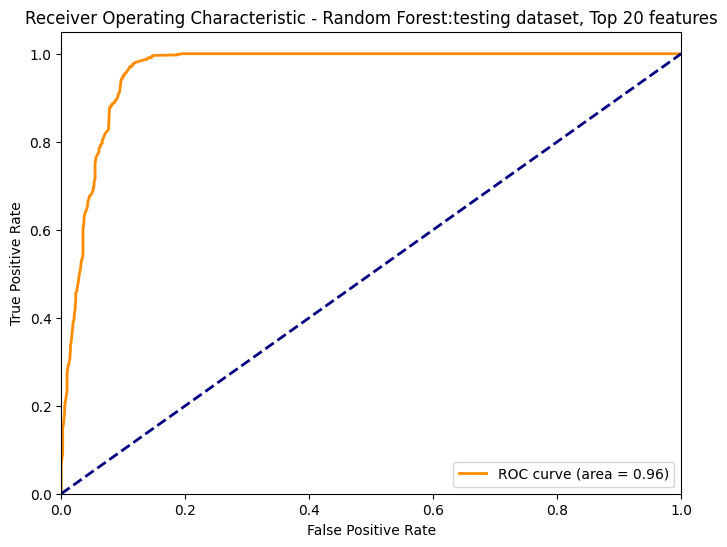

Confusion Matrix:
 [[1164  121]
 [  66  695]]


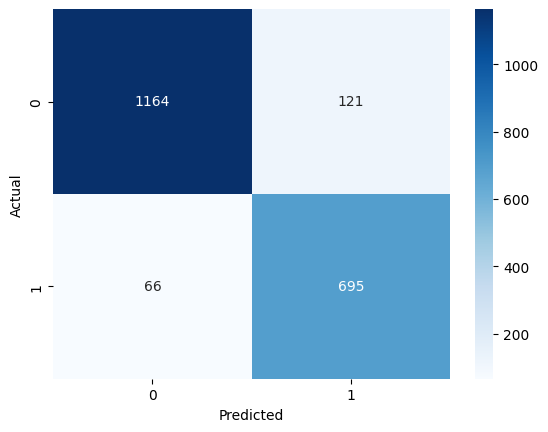

In [68]:
# Get feature importances
importances = pd.Series(rf_model.feature_importances_, index=X.columns)

# Select top 20 features
top_features = importances.nlargest(20).index
# positive_seq=['K44-K22',
#            'K20-K29-K22','K44-K22-K31','K29-K22-K31','I51-I25-I50-E87']
rf_top_features = top_features.tolist()

# Refit model using only those top features
rf_top = RandomForestClassifier(n_estimators=10, random_state=42)
rf_top.fit(X[rf_top_features], y)

y_pred=rf_top.predict(X_test[rf_top_features])
print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0))
# Predict probabilities
y_probs = rf_top.predict_proba(X_test[rf_top_features])[:, 1]

# Calculate the ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic - Random Forest:testing dataset, Top 20 features')
plt.legend(loc="lower right")
plt.show()

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


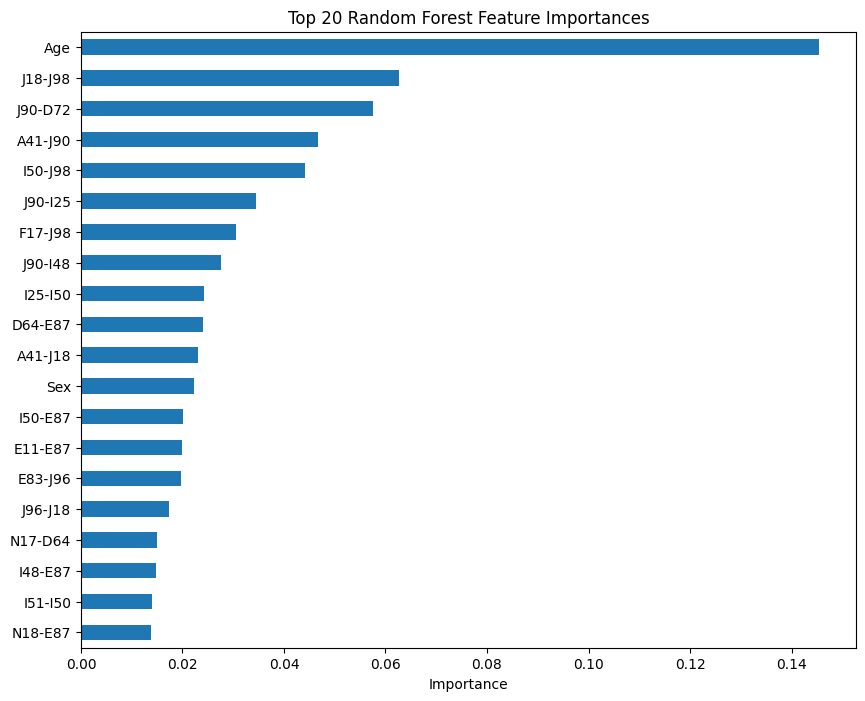

In [69]:
# Get feature importances (by default, "weight")
importances = pd.Series(rf_model.feature_importances_, index=X.columns)

# Select top 20 features
top_features = importances.nlargest(20)
# Plot horizontal bar chart
plt.figure(figsize=(10,8))
top_features.sort_values().plot(kind='barh')
plt.title("Top 20 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.show()

Classification Report: Random forest, evaluated on the training dataset
              precision    recall  f1-score   support

           0       0.97      0.90      0.93      3068
           1       0.83      0.95      0.89      1705

    accuracy                           0.92      4773
   macro avg       0.90      0.92      0.91      4773
weighted avg       0.92      0.92      0.92      4773



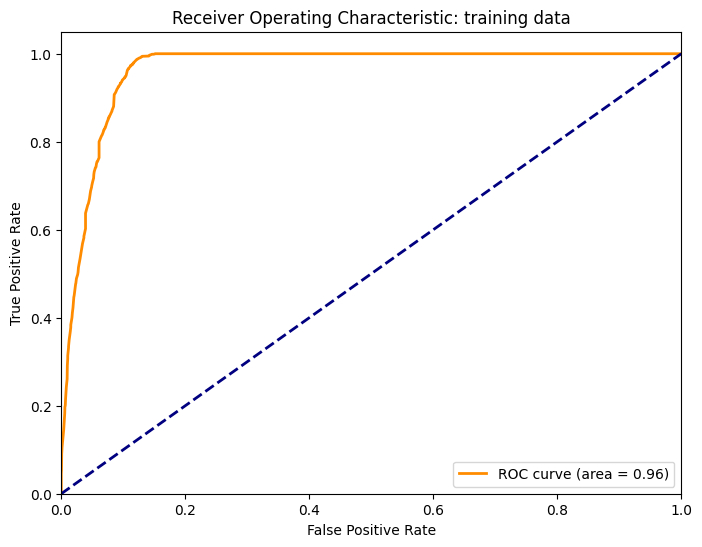

Confusion Matrix:
 [[2747  321]
 [  84 1621]]


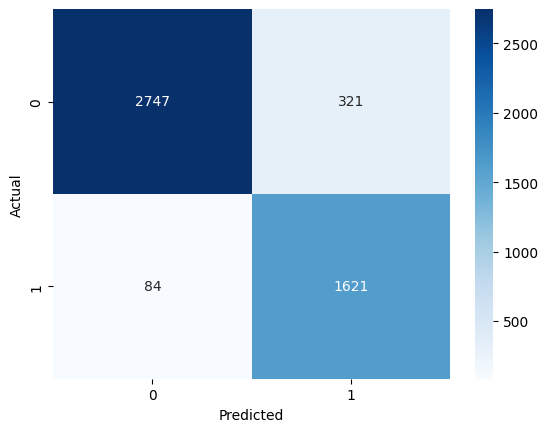

In [70]:
#troubleshooting, find out reason for poort model performance
#evaluate model on the training dataset
y_pred = rf_top.predict(X_train[rf_top_features])
accuracy = accuracy_score(y_train, y_pred)
precision = precision_score(y_train, y_pred, zero_division=0)
print("Classification Report: Random forest, evaluated on the training dataset")
print(classification_report(y_train, y_pred, zero_division=0))
from sklearn.metrics import roc_curve, auc
# Calculate the ROC curve and AUC
y_probs = rf_top.predict_proba(X_train[rf_top_features])[:, 1]
fpr, tpr, thresholds = roc_curve(y_train, y_probs)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic: training data')
plt.legend(loc="lower right")
plt.show()

# Confusion matrix
cm = confusion_matrix(y_train, y_pred)
print("Confusion Matrix:\n", cm)
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [71]:
RF_top20=rf_top_features

#### 6.3.3 XGBoost

Accuracy: 0.8484848484848485
XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.88      0.88      1285
           1       0.80      0.79      0.79       761

    accuracy                           0.85      2046
   macro avg       0.84      0.84      0.84      2046
weighted avg       0.85      0.85      0.85      2046



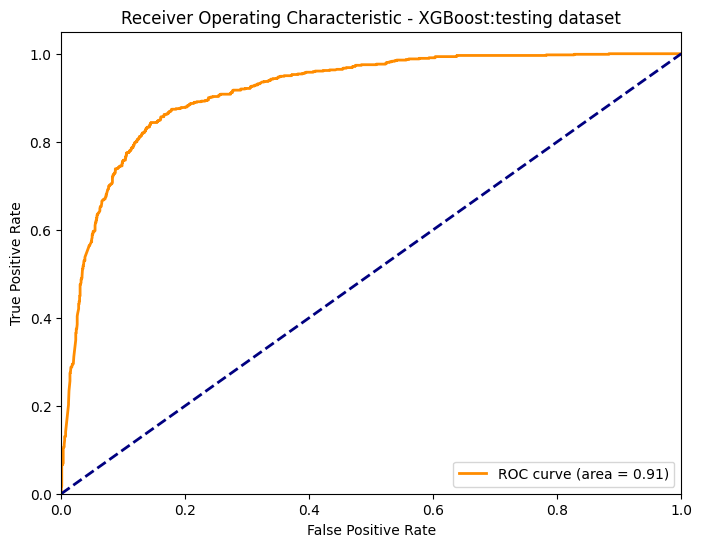

Confusion Matrix:
 [[1136  149]
 [ 161  600]]


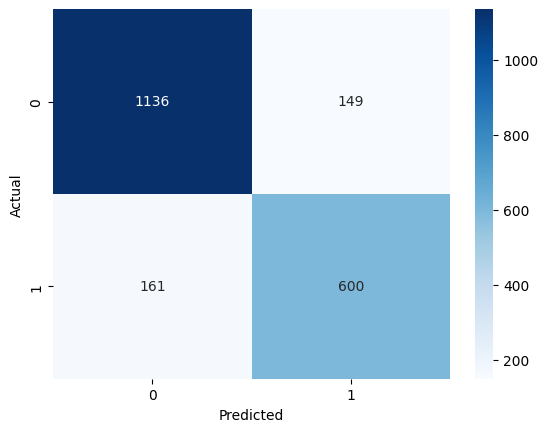

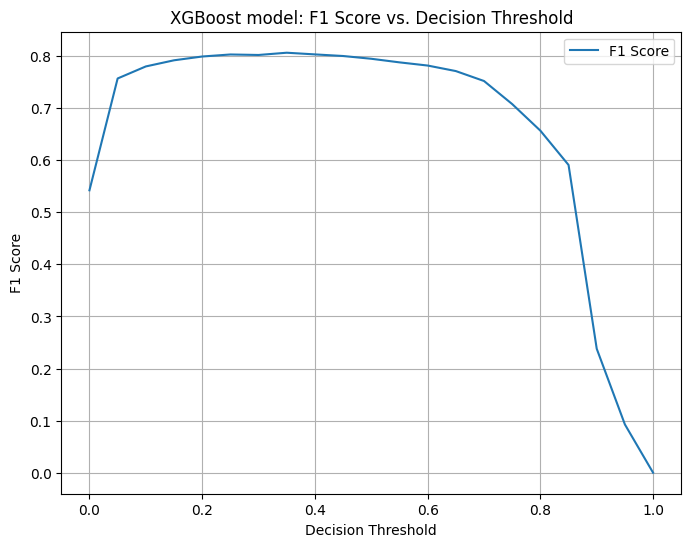

array([0.35])

In [72]:
import xgboost as xgb
# Train XGBoost classifier
xgb_model = xgb.XGBClassifier(objective="binary:logistic", random_state=42)
xgb_model.fit(X_train, y_train)

y_pred = xgb_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print("XGBoost Classification Report:")
print(classification_report(y_test, y_pred))

# Predict probabilities
y_probs = xgb_model.predict_proba(X_test)[:, 1]

# Calculate the ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic - XGBoost:testing dataset')
plt.legend(loc="lower right")
plt.show()

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


#change the decisionthrehsold to improve model prediction 
# Define thresholds
thresholds = np.arange(0, 1.01, 0.05)


# Calculate F1 scores for each threshold
f1_scores = [f1_score(y_test, y_probs >= t) for t in thresholds]
# Find the threshold with the maximum F1 score
max_f1 = max(f1_scores)
optimal_thresholds = thresholds[np.array(f1_scores) == max_f1]
# Plot F1 score against decision threshold
plt.figure(figsize=(8, 6))
plt.plot(thresholds, f1_scores, label='F1 Score')
plt.xlabel('Decision Threshold')
plt.ylabel('F1 Score')
plt.title('XGBoost model: F1 Score vs. Decision Threshold')
plt.grid(True)
plt.legend()
plt.show()
optimal_thresholds

Classification Report: XGBoosting, evaluated on the training dataset
              precision    recall  f1-score   support

           0       0.97      0.91      0.94      3068
           1       0.85      0.95      0.90      1705

    accuracy                           0.92      4773
   macro avg       0.91      0.93      0.92      4773
weighted avg       0.93      0.92      0.92      4773



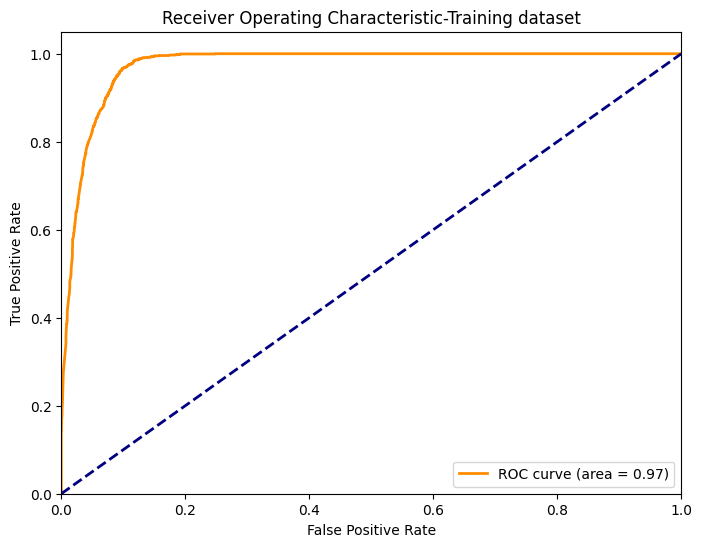

In [73]:
#trouble shooting, find out reason for poort model performance
#evaluate model on the training dataset
y_pred = xgb_model.predict(X_train)
accuracy = accuracy_score(y_train, y_pred)
precision = precision_score(y_train, y_pred, zero_division=0)
print("Classification Report: XGBoosting, evaluated on the training dataset")
print(classification_report(y_train, y_pred, zero_division=0))
from sklearn.metrics import roc_curve, auc
# Calculate the ROC curve and AUC
y_probs = xgb_model.predict_proba(X_train)[:, 1]
fpr, tpr, thresholds = roc_curve(y_train, y_probs)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic-Training dataset')
plt.legend(loc="lower right")
plt.show()

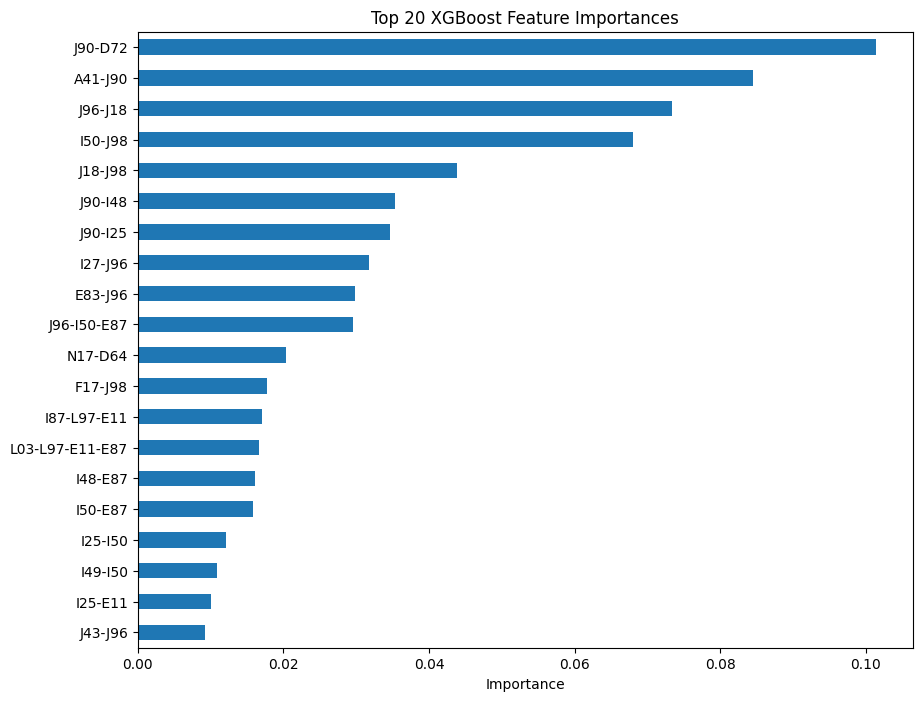

In [74]:
# Get feature importances (by default, "weight")
importances = pd.Series(xgb_model.feature_importances_, index=X.columns)

# Select top 20 features
top_features = importances.nlargest(20)

# Plot horizontal bar chart
plt.figure(figsize=(10,8))
top_features.sort_values().plot(kind='barh')
plt.title("Top 20 XGBoost Feature Importances")
plt.xlabel("Importance")
plt.show()

Accuracy: 0.8499511241446726
XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.89      0.88      1285
           1       0.81      0.78      0.80       761

    accuracy                           0.85      2046
   macro avg       0.84      0.84      0.84      2046
weighted avg       0.85      0.85      0.85      2046



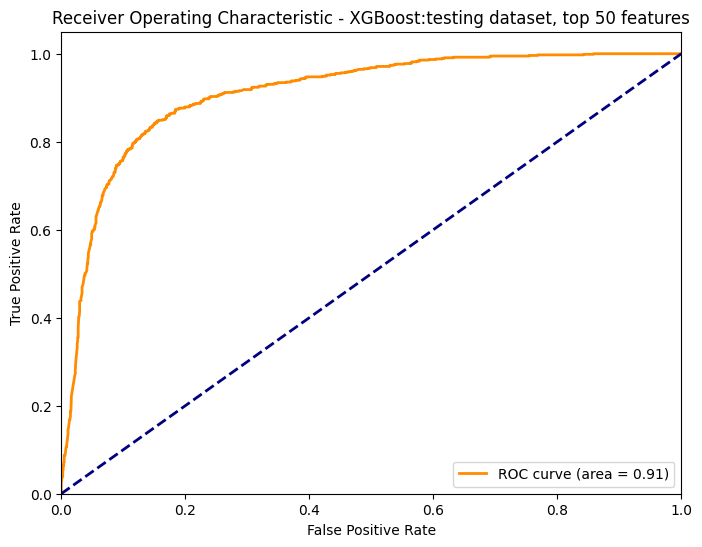

Confusion Matrix:
 [[1143  142]
 [ 165  596]]


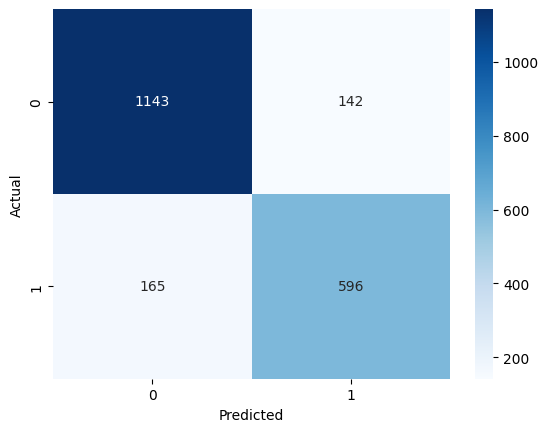

In [75]:
top_10 = importances.nlargest(50).index
xgb_top_features=top_10.tolist()
xgb_model = xgb.XGBClassifier(objective="binary:logistic", random_state=42)
xgb_model.fit(X_train[xgb_top_features], y_train)

y_pred = xgb_model.predict(X_test[xgb_top_features])
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

print("XGBoost Classification Report:")
print(classification_report(y_test, y_pred))


# Predict probabilities
y_probs = xgb_model.predict_proba(X_test[xgb_top_features])[:, 1]

# Calculate the ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic - XGBoost:testing dataset, top 50 features')
plt.legend(loc="lower right")
plt.show()

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [76]:
XGB_top50=xgb_top_features

In [77]:
df_comp=pd.concat([X_test[xgb_top_features],y_test],axis=1)
df_comp['y_pred']=y_pred

In [78]:
df_comp.shape

(2046, 52)

In [79]:
mask = (df_comp[xgb_top_features] == 0).all(axis=1)
df_comp_zeros = df_comp[mask]
df_comp_zeros

,J90-D72,A41-J90,J96-J18,I50-J98,J18-J98,J90-I48,J90-I25,I27-J96,E83-J96,J96-I50-E87,...,J44-D72,D64-N18-E87,J96-E66,J96-I50,D72-J18,K44-K22-J98,D64-K31,Age,gastric_cancer_dx,y_pred


In [80]:
df_comp_zeros['y_pred'].value_counts()

Series([], Name: count, dtype: int64)

In [81]:
df_comp_zeros['gastric_cancer_dx'].value_counts()

Series([], Name: count, dtype: int64)

In [82]:
df_comp_zeros[(df_comp_zeros['gastric_cancer_dx']==1) & (df_comp_zeros['y_pred']==1)].shape

(0, 52)

In [ ]:
#model optimization

xgb_clf = xgb.XGBClassifier(
    max_depth=5, 
    learning_rate=0.05,
    n_estimators=1000,
    subsample=0.8,
    colsample_bytree=0.8
)

xgb_clf.fit(
    X_train[xgb_top_features], y_train,
    eval_set=[(X_test[xgb_top_features], y_test)],
    eval_metric='auc',
    early_stopping_rounds=50,
    verbose=True
)


[0]	validation_0-auc:0.78013
[1]	validation_0-auc:0.82574
[2]	validation_0-auc:0.83527
[3]	validation_0-auc:0.83476
[4]	validation_0-auc:0.83697
[5]	validation_0-auc:0.85160
[6]	validation_0-auc:0.85220
[7]	validation_0-auc:0.85185
[8]	validation_0-auc:0.85286
[9]	validation_0-auc:0.85717
[10]	validation_0-auc:0.85703
[11]	validation_0-auc:0.85745
[12]	validation_0-auc:0.85987
[13]	validation_0-auc:0.86975
[14]	validation_0-auc:0.87040
[15]	validation_0-auc:0.87096
[16]	validation_0-auc:0.87151
[17]	validation_0-auc:0.88240
[18]	validation_0-auc:0.88107
[19]	validation_0-auc:0.88134
[20]	validation_0-auc:0.88154
[21]	validation_0-auc:0.88434
[22]	validation_0-auc:0.88442
[23]	validation_0-auc:0.88463
[24]	validation_0-auc:0.88508
[25]	validation_0-auc:0.88401
[26]	validation_0-auc:0.88588
[27]	validation_0-auc:0.88588
[28]	validation_0-auc:0.88599
[29]	validation_0-auc:0.88616
[30]	validation_0-auc:0.88690
[31]	validation_0-auc:0.88745
[32]	validation_0-auc:0.88739
[33]	validation_0-au

[268]	validation_0-auc:0.90927
[269]	validation_0-auc:0.90923
[270]	validation_0-auc:0.90915
[271]	validation_0-auc:0.90921
[272]	validation_0-auc:0.90918
[273]	validation_0-auc:0.90915
[274]	validation_0-auc:0.90910
[275]	validation_0-auc:0.90913
[276]	validation_0-auc:0.90914
[277]	validation_0-auc:0.90915
[278]	validation_0-auc:0.90922
[279]	validation_0-auc:0.90922
[280]	validation_0-auc:0.90926
[281]	validation_0-auc:0.90919
[282]	validation_0-auc:0.90930
[283]	validation_0-auc:0.90936
[284]	validation_0-auc:0.90929
[285]	validation_0-auc:0.90930
[286]	validation_0-auc:0.90934
[287]	validation_0-auc:0.90933
[288]	validation_0-auc:0.90937
[289]	validation_0-auc:0.90940
[290]	validation_0-auc:0.90932
[291]	validation_0-auc:0.90930
[292]	validation_0-auc:0.90934
[293]	validation_0-auc:0.90900
[294]	validation_0-auc:0.90896
[295]	validation_0-auc:0.90900
[296]	validation_0-auc:0.90900
[297]	validation_0-auc:0.90895
[298]	validation_0-auc:0.90893
[299]	validation_0-auc:0.90896
[300]	va

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=1000, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

Accuracy: 0.8514173998044966
XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.87      0.88      1285
           1       0.79      0.82      0.80       761

    accuracy                           0.85      2046
   macro avg       0.84      0.84      0.84      2046
weighted avg       0.85      0.85      0.85      2046



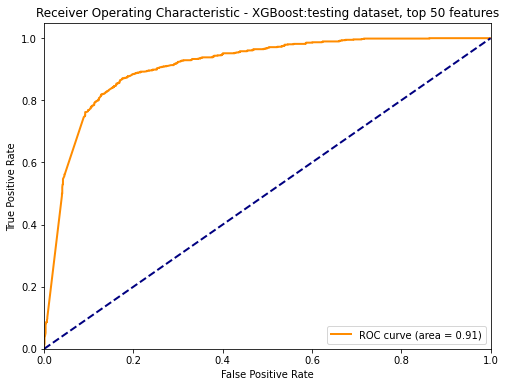

Confusion Matrix:
 [[1121  164]
 [ 140  621]]


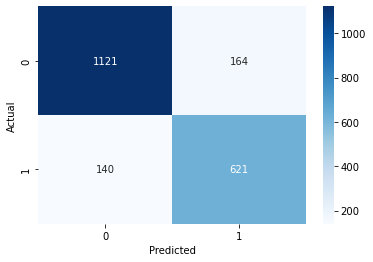

In [ ]:
y_pred = xgb_clf.predict(X_test[xgb_top_features])
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

print("XGBoost Classification Report:")
print(classification_report(y_test, y_pred))


# Predict probabilities
y_probs = xgb_clf.predict_proba(X_test[xgb_top_features])[:, 1]

# Calculate the ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic - XGBoost:testing dataset, top 50 features')
plt.legend(loc="lower right")
plt.show()

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### 6.3.4. Light GBM

[LightGBM] [Info] Number of positive: 1705, number of negative: 3068
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.067112 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 289
[LightGBM] [Info] Number of data points in the train set: 4773, number of used features: 100
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.357218 -> initscore=-0.587461
[LightGBM] [Info] Start training from score -0.587461
Accuracy: 0.8484848484848485
Light GBM Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.84      0.87      1285
           1       0.76      0.86      0.81       761

    accuracy                           0.85      2046
   macro avg       0.84      0.85      0.84      2046
weighted avg       0.85      0.85      0.85      2046



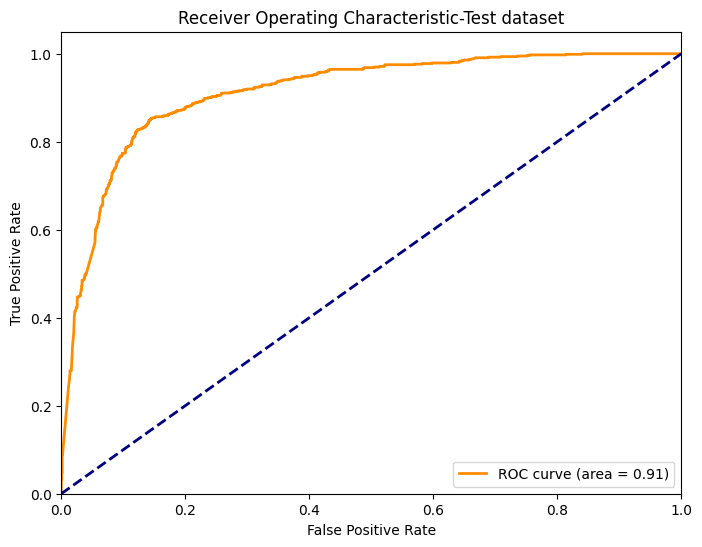

Confusion Matrix:
 [[1084  201]
 [ 109  652]]


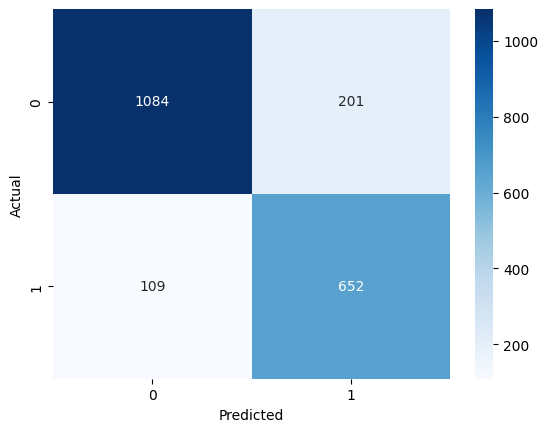

In [91]:
import lightgbm as lgb

# 1. Create LightGBM dataset format (optional, but useful for advanced usage)
train_data = lgb.Dataset(X_train, label=y_train)
test_data = lgb.Dataset(X_test, label=y_test, reference=train_data)

# 4. Define parameters
params = {
    'objective': 'binary',       # binary classification
    'metric': ['binary_logloss', 'auc'],
    'boosting_type': 'gbdt',     # gradient boosting decision tree
    'num_leaves': 31,            # complexity of the trees
    'learning_rate': 0.05,
    'feature_fraction': 0.9
}

# 5. Train the model
model = lgb.train(
    params,
    train_data,
    valid_sets=[train_data, test_data],
    num_boost_round=100
)

# Calculate the ROC curve and AUC
y_probs = model.predict(X_test, num_iteration=model.best_iteration)
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

y_pred = (y_probs >= 0.3).astype(int)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print("Light GBM Classification Report:")
print(classification_report(y_test, y_pred))

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic-Test dataset')
plt.legend(loc="lower right")
plt.show()

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [96]:
#get feature importance
importance_gain = model.feature_importance(importance_type='gain')
feature_names = model.feature_name()

import pandas as pd

df_importance = pd.DataFrame({
    "feature": feature_names,
    "gain_importance": importance_gain
}).sort_values(by="gain_importance", ascending=False)

df_importance.head(20)

,feature,gain_importance
65,J90-D72,4981.314083
61,A41-J90,4115.575380
27,I50-J98,3597.374913
0,Age,3211.862967
24,J18-J98,2969.468457
50,J90-I25,2286.161955
60,J90-I48,1711.493562
72,E83-J96,1216.959218
8,I25-I50,968.464712
56,J96-J18,933.854314


[LightGBM] [Info] Number of positive: 1705, number of negative: 3068
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001371 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 189
[LightGBM] [Info] Number of data points in the train set: 4773, number of used features: 50
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.357218 -> initscore=-0.587461
[LightGBM] [Info] Start training from score -0.587461
Accuracy: 0.8455522971652004
Light GBM Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.84      0.87      1285
           1       0.76      0.85      0.80       761

    accuracy                           0.85      2046
   macro avg       0.83      0.85      0.84      2046
weighted avg       0.85      0.85      0.85      2046



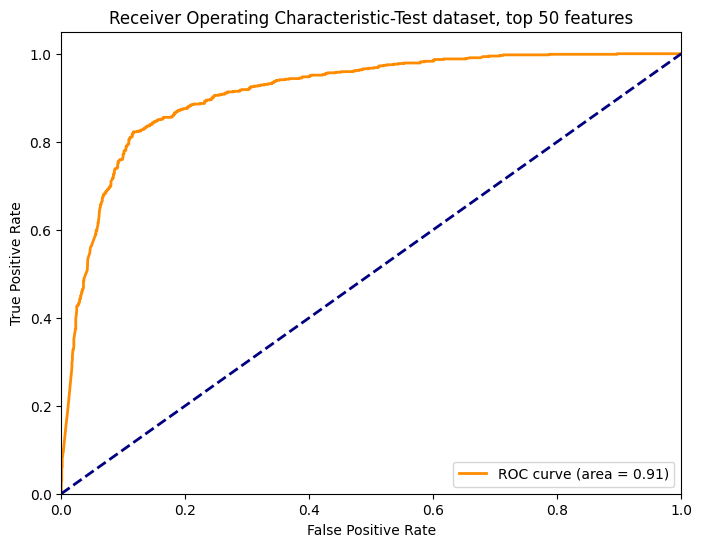

Confusion Matrix:
 [[1084  201]
 [ 115  646]]


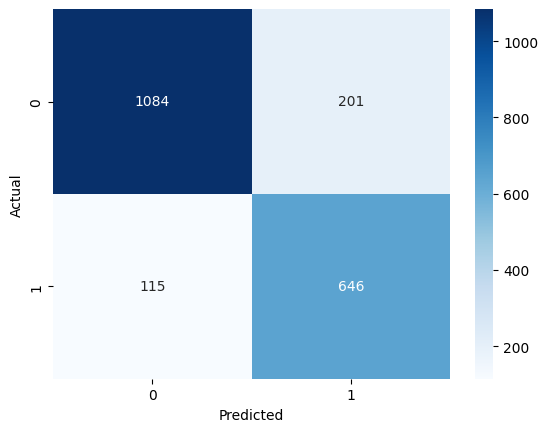

In [98]:
lgb_top50=df_importance.head(50)['feature'].tolist()
# 1. Create LightGBM dataset format (optional, but useful for advanced usage)
train_data = lgb.Dataset(X_train[lgb_top50], label=y_train)
test_data = lgb.Dataset(X_test[lgb_top50], label=y_test, reference=train_data)

# 4. Define parameters
params = {
    'objective': 'binary',       # binary classification
    'metric': ['binary_logloss', 'auc'],
    'boosting_type': 'gbdt',     # gradient boosting decision tree
    'num_leaves': 31,            # complexity of the trees
    'learning_rate': 0.05,
    'feature_fraction': 0.9
}

# 5. Train the model
model = lgb.train(
    params,
    train_data,
    valid_sets=[train_data, test_data],
    num_boost_round=100
)

# Calculate the ROC curve and AUC
y_probs = model.predict(X_test[lgb_top50], num_iteration=model.best_iteration)
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

y_pred = (y_probs >= 0.3).astype(int)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print("Light GBM Classification Report:")
print(classification_report(y_test, y_pred))

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic-Test dataset, top 50 features')
plt.legend(loc="lower right")
plt.show()

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

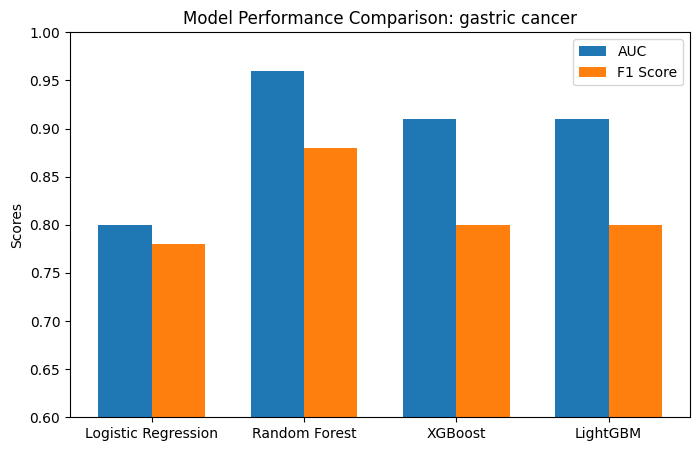

In [103]:
### Create a bar graph to compare the perormance of the 4 models
model_names = ['Logistic Regression', 'Random Forest', 'XGBoost', 'LightGBM']
AUCs = [0.80,0.96,0.91,0.91]
F1_scores=[0.78,0.88,0.80,0.80]
import matplotlib.pyplot as plt
import numpy as np  
x = np.arange(len(model_names))  # the label locations
width = 0.35  # the width of the bars   
fig, ax = plt.subplots(figsize=(8, 5))
rects1 = ax.bar(x - width/2, AUCs, width, label='AUC')
rects2 = ax.bar(x + width/2, F1_scores, width, label='F1 Score')
ax.set_ylabel('Scores')
ax.set_title('Model Performance Comparison: gastric cancer')
ax.set_xticks(x)
ax.set_xticklabels(model_names) 
ax.legend()
plt.ylim(0.6, 1)
plt.show()


### 7. timing of last sequence full model
<span style="color:blue">Update since meeting on 10/24/25 with Dr Kothari</span>

In [84]:
var_list=significant_vars['variable'].unique().tolist()+['last_event_date','gastric_cancer_dx','Whio_MemberId']

In [85]:
#subset the gastric_seq_ananlysis dataframe. taking all columns related to those in the significant_vars list
sig_cols=[col for col in gastric_seq_analysis.columns if any(col.startswith(name) for name in var_list)]
df_last_timing=gastric_seq_analysis[sig_cols]

In [86]:
#get all _end columns
end_cols=[c for c in df_last_timing.columns if '_end' in c.lower()]
date_cols=end_cols+['last_event_date']
#comvert all date columsn to datetime
df_last_timing[date_cols] = df_last_timing[date_cols].apply(pd.to_datetime, errors='coerce')

#compute the lastest event end dates across those columns
df_last_timing['last_seq_date']=df_last_timing[end_cols].max(axis=1)
#compute time between last sequence and last event date
df_last_timing['last_seq_to_last_event']=(df_last_timing['last_event_date']-df_last_timing['last_seq_date']).dt.days

In [87]:
#get the second last event-sequence date based on end date
df_last_timing['last_seq_to_last_event'].describe()

count    5249.000000
mean      296.260240
std       474.755868
min         0.000000
25%         9.000000
50%        78.000000
75%       377.000000
max      3055.000000
Name: last_seq_to_last_event, dtype: float64

In [88]:
df_last_timing['last_seq_to_last_event'].median()

np.float64(78.0)

In [89]:
gastric_only=df_last_timing[df_last_timing['gastric_cancer_dx']==1]
gastric_only['last_seq_to_last_event'].describe()

count    1188.000000
mean      211.389731
std       366.308880
min         1.000000
25%        13.000000
50%        50.500000
75%       228.000000
max      2386.000000
Name: last_seq_to_last_event, dtype: float64

### *. Timing of last sequence - best models

In [ ]:
var_list=RF_top20+['last_event_date','gastric_cancer_dx','Whio_MemberId']
#subset the gastric_seq_ananlysis dataframe. taking all columns related to those in the significant_vars list
sig_cols=[col for col in gastric_seq_analysis.columns if any(col.startswith(name) for name in var_list)]
df_last_timing=gastric_seq_analysis[sig_cols]
#get all _end columns
end_cols=[c for c in df_last_timing.columns if '_end' in c.lower()]
date_cols=end_cols+['last_event_date']
#comvert all date columsn to datetime
df_last_timing[date_cols] = df_last_timing[date_cols].apply(pd.to_datetime, errors='coerce')

#compute the lastest event end dates across those columns
df_last_timing['last_seq_date']=df_last_timing[end_cols].max(axis=1)
#compute time between last sequence and last event date
df_last_timing['last_seq_to_last_event']=(df_last_timing['last_event_date']-df_last_timing['last_seq_date']).dt.days
#get the second last event-sequence date based on end date
df_last_timing['last_seq_to_last_event'].describe()

count    4485.000000
mean      457.647938
std       607.824519
min         0.000000
25%        22.000000
50%       184.000000
75%       668.000000
max      3055.000000
Name: last_seq_to_last_event, dtype: float64

In [ ]:
gastric_only=df_last_timing[df_last_timing['gastric_cancer_dx']==1]
gastric_only['last_seq_to_last_event'].describe()

count     634.000000
mean      303.998423
std       431.895065
min         1.000000
25%        20.000000
50%       115.000000
75%       406.000000
max      2414.000000
Name: last_seq_to_last_event, dtype: float64

In [ ]:
var_list=XGB_top50+['last_event_date','gastric_cancer_dx','Whio_MemberId']
#subset the gastric_seq_ananlysis dataframe. taking all columns related to those in the significant_vars list
sig_cols=[col for col in gastric_seq_analysis.columns if any(col.startswith(name) for name in var_list)]
df_last_timing=gastric_seq_analysis[sig_cols]
#get all _end columns
end_cols=[c for c in df_last_timing.columns if '_end' in c.lower()]
date_cols=end_cols+['last_event_date']
#comvert all date columsn to datetime
df_last_timing[date_cols] = df_last_timing[date_cols].apply(pd.to_datetime, errors='coerce')

#compute the lastest event end dates across those columns
df_last_timing['last_seq_date']=df_last_timing[end_cols].max(axis=1)
#compute time between last sequence and last event date
df_last_timing['last_seq_to_last_event']=(df_last_timing['last_event_date']-df_last_timing['last_seq_date']).dt.days
#get the second last event-sequence date based on end date
df_last_timing['last_seq_to_last_event'].describe()

count    4927.000000
mean      381.088898
std       546.669442
min         0.000000
25%        15.000000
50%       131.000000
75%       526.500000
max      3055.000000
Name: last_seq_to_last_event, dtype: float64

In [ ]:
gastric_only=df_last_timing[df_last_timing['gastric_cancer_dx']==1]
gastric_only['last_seq_to_last_event'].describe()

count     935.000000
mean      301.995722
std       440.894752
min         1.000000
25%        20.000000
50%       104.000000
75%       401.000000
max      2424.000000
Name: last_seq_to_last_event, dtype: float64

In [ ]:
xgb_positive=list(set(positive_seq['Sequence'].unique()) & set(XGB_top50))
xgb_positive

['L97-I48-E11',
 'K56-C18',
 'I25-I50-I48-E11',
 'K63-C18',
 'E66-E11',
 'D64-N18-E11',
 'L97-E11',
 'I87-L97-E11',
 'L03-L97-E11-E87']

In [ ]:
RF_positive=list(set(positive_seq['Sequence'].unique()) & set(RF_top20))
RF_positive

[]

### 9. Modeling with risk sequences only

In [ ]:
xgb_risk=set(xgb_top_features) &set (positive_seq['Sequence'].unique())

In [ ]:
xgb_risk

{'D64-N18-E11',
 'E66-E11',
 'I25-I50-I48-E11',
 'I87-L97-E11',
 'K56-C18',
 'K63-C18',
 'L03-L97-E11-E87',
 'L97-E11',
 'L97-I48-E11'}

Accuracy: 0.6309872922776149
XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.89      0.75      1285
           1       0.51      0.20      0.28       761

    accuracy                           0.63      2046
   macro avg       0.58      0.54      0.52      2046
weighted avg       0.60      0.63      0.58      2046



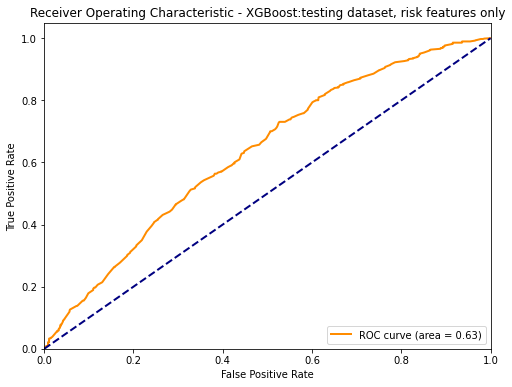

Confusion Matrix:
 [[1141  144]
 [ 611  150]]


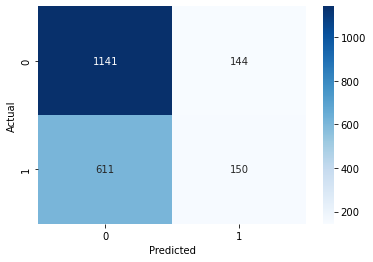

In [ ]:
xgb_risk_features=list(xgb_risk)['Age','Sex']
xgb_model = xgb.XGBClassifier(objective="binary:logistic", random_state=42)
xgb_model.fit(X_train[xgb_risk_features], y_train)

y_pred = xgb_model.predict(X_test[xgb_risk_features])
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

print("XGBoost Classification Report:")
print(classification_report(y_test, y_pred))


# Predict probabilities
y_probs = xgb_model.predict_proba(X_test[xgb_risk_features])[:, 1]

# Calculate the ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic - XGBoost:testing dataset, risk features only')
plt.legend(loc="lower right")
plt.show()

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
var_list=xgb_risk_features+['last_event_date','gastric_cancer_dx','Whio_MemberId']
#subset the gastric_seq_ananlysis dataframe. taking all columns related to those in the significant_vars list
sig_cols=[col for col in gastric_seq_analysis.columns if any(col.startswith(name) for name in var_list)]
df_last_timing=gastric_seq_analysis[sig_cols]
#get all _end columns
end_cols=[c for c in df_last_timing.columns if '_end' in c.lower()]
date_cols=end_cols+['last_event_date']
#comvert all date columsn to datetime
df_last_timing[date_cols] = df_last_timing[date_cols].apply(pd.to_datetime, errors='coerce')

#compute the lastest event end dates across those columns
df_last_timing['last_seq_date']=df_last_timing[end_cols].max(axis=1)
#compute time between last sequence and last event date
df_last_timing['last_seq_to_last_event']=(df_last_timing['last_event_date']-df_last_timing['last_seq_date']).dt.days
#get the second last event-sequence date based on end date
df_last_timing['last_seq_to_last_event'].describe()

count     633.000000
mean      642.458136
std       633.146654
min         0.000000
25%       139.000000
50%       433.000000
75%       978.000000
max      2995.000000
Name: last_seq_to_last_event, dtype: float64

In [ ]:
gastric_only=df_last_timing[df_last_timing['gastric_cancer_dx']==1]
gastric_only['last_seq_to_last_event'].describe()

count     326.000000
mean      492.613497
std       509.463541
min         1.000000
25%       109.250000
50%       356.500000
75%       675.500000
max      2367.000000
Name: last_seq_to_last_event, dtype: float64